In [1]:
from statsmodels.genmod.families.links import *
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cskpd_new import *

Kept the Y values as is in the simulation because the C value is what we are seeking to predict Y and the signal should be the same in all images. This detects variances in the selected signal region not necessarily that X "looks like" C. See c_true_random.ipynb for details.

In [2]:
g = Logit()
C_true = np.load("Examples/circles.npy")
np.random.seed(539)
## image shape
img_shape_m,img_shape_n,img_shape_d = 128,128,1
## sample size 
N = 1000
## noise level
sigma = 10
epsilon = np.random.normal(0,1,N) * sigma
X = np.random.normal(0,1,[N, img_shape_m, img_shape_n, img_shape_d]).squeeze()
if isinstance(g, Identity):
    Y = g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon)
elif isinstance(g, Logit):
    Y = np.random.binomial(1,g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon))
else:
    raise NotImplementedError

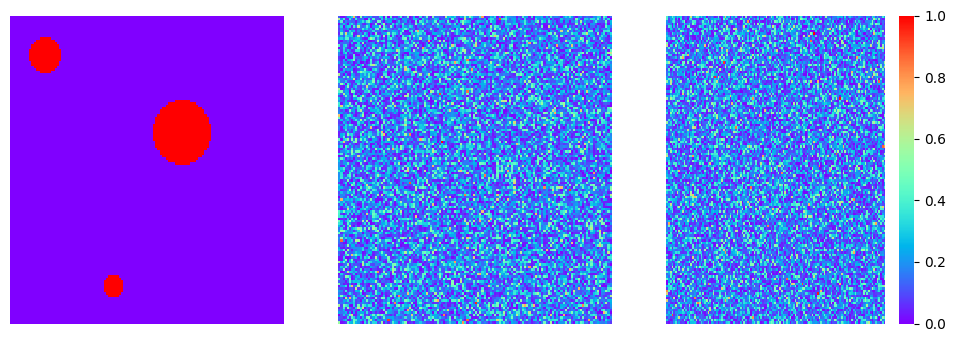

In [3]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(X[np.where(Y==0)[0][0]]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(X[np.where(Y==1)[0][0]]),cmap = "rainbow",cbar = True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [4]:
p_list = [[16,16],[32,32]]
lam = [2**i for i in range(5,6)]
test_model = CSKPD(p_list,lama=lam,lamb=lam,R=3,g=g,n_cores = 12,max_iter = 3,print_iter = 5)
test_model.fit(X,Y,tol=1E-3)
C_mbic = test_model.C

In [5]:
print_vars = ["lama","lamb","p","R","MSE","print_detail"]
for p in test_model.parameters:
    print({k: v for k, v in p.items() if k in print_vars}) #test_model.parameters

{'lama': 32, 'lamb': 32, 'p': [16, 16], 'R': 3}
{'lama': 32, 'lamb': 32, 'p': [32, 32], 'R': 3}


In [6]:
test_model.grid_values['score']['history']

[array([ 1.73205081, 12.82585111,  0.        ]),
 array([ 0.        , -0.25856346,  0.        ]),
 array([ 0.        , -0.24964426,  0.        ]),
 array([ 0.        , -0.09306046,  0.        ])]

In [7]:
test_model.grid_values['print_detail']

['Iter: 3, Instability: 0.5%, Sparsity: 94.0%, MSE: 624.31, MBIC: 47.25, dif: [ 0.         -0.01226681  0.        ], zeta: None',
 'Iter: 3, Instability: 1.4%, Sparsity: 94.9%, MSE: 515.39, MBIC: 15.01, dif: [ 0.         -0.09306046  0.        ], zeta: None']

In [8]:
C_mbic = test_model.C
print(C_mbic)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


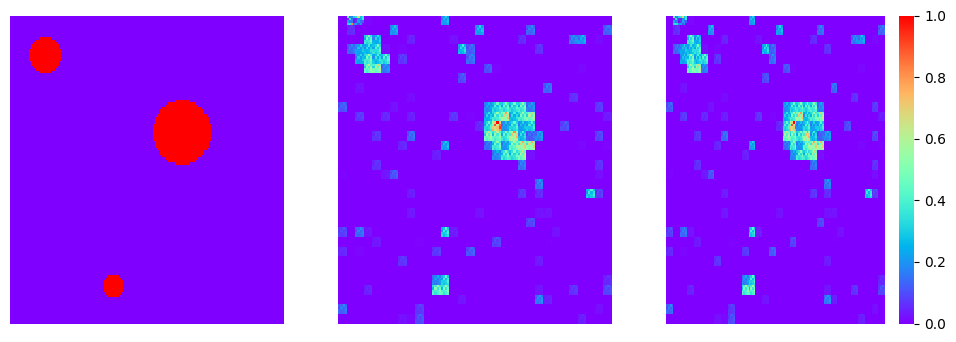

In [9]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(C_mbic),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(C_mbic),cmap = "rainbow",cbar = True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [10]:
scorers = {
    'MSE': mean_squared_error,
    'AUC': auc
}

In [11]:
p_list = [[16,16],[32,32],[16,32],[32,16]]
lam = [2**i for i in range(-2, 2)]
test_model2 = CSKPD(p_list,lama=lam,lamb=lam,R=3,g=g,n_cores = 12,max_iter = 20,print_iter = 5)
t1 = test_model.custom_cross_validate(X,Y,scorers=scorers)

In [12]:
print_vars = ["lama","lamb","p","R","MSE","print_detail"]
for p in test_model.parameters:
    print({k: v for k, v in p.items() if k in print_vars}) #test_model.parameters

{'lama': 32, 'lamb': 32, 'p': [16, 16], 'R': 3}
{'lama': 32, 'lamb': 32, 'p': [32, 32], 'R': 3}


In [13]:
for ti in t1:
    print(ti['results']['test_AUC'])

[0.65504808]
[0.65504808 0.71514423]
[0.65504808 0.71514423 0.72155449]
[0.65504808 0.71514423 0.72155449 0.69871795]
[0.65504808 0.71514423 0.72155449 0.69871795 0.64057652]


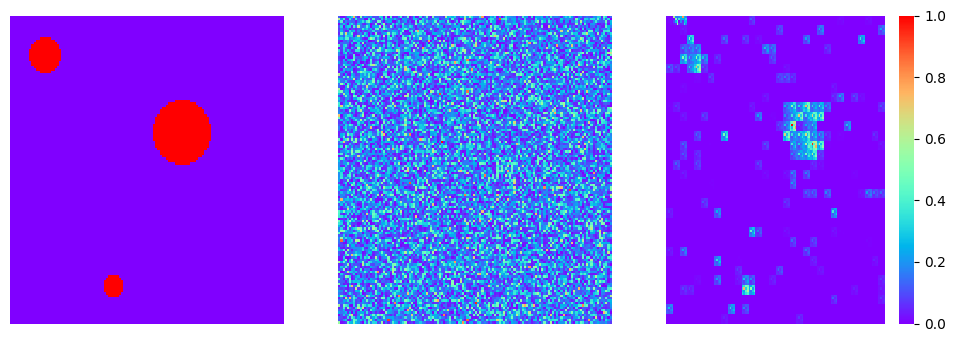

In [14]:
plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(X[0]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(t1[np.argmax(t1[4]['results'])]['model'].C),cmap = "rainbow",cbar = True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [16]:
with np.printoptions(threshold=np.inf, suppress=True):
    print("\nLarge Matrix with All Values Displayed:")
    print(t1[1]['model'].grid_values['B'])


Large Matrix with All Values Displayed:
[[-3.77091609 -0.934942   -0.63889516]
 [-5.01862198 -0.11552983  1.57256989]
 [-8.57837753  0.20888834  0.67942171]
 [-5.14038763 -0.47631357 -0.6423112 ]
 [-5.05195752  0.43371374  0.0352317 ]
 [-9.14942223 -0.6638186   0.70035774]
 [-5.62592858 -0.30990171  0.33628345]
 [-7.79410389  0.74230951 -1.68281577]
 [-5.2774769   1.49325633  0.05311034]
 [-4.5328919  -0.11736216  0.16103881]
 [-6.89882429 -0.14407616  0.30055354]
 [-9.21722801 -0.49141544  0.27324028]
 [-7.81213082  0.40340749  0.06370649]
 [-3.93660948  0.73790253 -0.13093818]
 [-5.81379634 -1.68343552  0.37455004]
 [-7.50384244  0.07062607  0.51676894]]


[[-3.77091609 -0.934942   -0.63889516]
 [-5.01862198 -0.11552983  1.57256989]
 [-8.57837753  0.20888834  0.67942171]
 [-5.14038763 -0.47631357 -0.6423112 ]
 [-5.05195752  0.43371374  0.0352317 ]
 [-9.14942223 -0.6638186   0.70035774]
 [-5.62592858 -0.30990171  0.33628345]
 [-7.79410389  0.74230951 -1.68281577]
 [-5.2774769   1.49325633  0.05311034]
 [-4.5328919  -0.11736216  0.16103881]
 [-6.89882429 -0.14407616  0.30055354]
 [-9.21722801 -0.49141544  0.27324028]
 [-7.81213082  0.40340749  0.06370649]
 [-3.93660948  0.73790253 -0.13093818]
 [-5.81379634 -1.68343552  0.37455004]
 [-7.50384244  0.07062607  0.51676894]]
[[-3.77091609 -0.934942   -0.63889516]
 [-5.01862198 -0.11552983  1.57256989]
 [-8.57837753  0.20888834  0.67942171]
 [-5.14038763 -0.47631357 -0.6423112 ]
 [-5.05195752  0.43371374  0.0352317 ]
 [-9.14942223 -0.6638186   0.70035774]
 [-5.62592858 -0.30990171  0.33628345]
 [-7.79410389  0.74230951 -1.68281577]
 [-5.2774769   1.49325633  0.05311034]
 [-4.5328919  -0.1173621

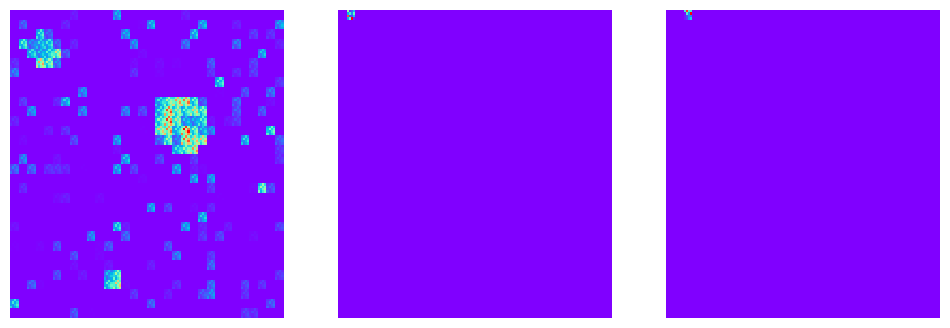

In [17]:
R=3
C=[]
for i in range(R):
    A = t1[1]['model'].grid_values['A'][:,i].reshape(t1[1]['model'].grid_values['p'])
    B = t1[1]['model'].grid_values['B'][:,i].reshape((4,4))
    with np.printoptions(threshold=np.inf, suppress=True):
        print(t1[1]['model'].grid_values['B'])
    C.append(np.kron(A,B))

plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C[0]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(C[1]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(C[2]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()